## Hospital Admissions Exploratory Data Analysis and Visualisations

# Executive Summary  
- The overall average length of stay was 7.46 days over 4120 admissions.  
- Admissions to the Surgical ward demonstrated the highest average length of stay (7.63). However, the variations between averages across wards was minimal.  
- The overall 30-day readmission rate was 11.5%. The ward with the highest readmission rate was the Respiratory ward at 14.68%.  
- Emergency admissions showed overall longer average length of stays (8.14) compared to patients undergoing elective procedures (6.04).  
- Patients who were 75+ had, on average, a 2 day higher length of stay (8.84) compared to other age groups who averaged between 6.05 and 6.78 days.
- Admission volume increased significantly during the winter months (Jan, Feb), indicating a seasonal trend.  

Please read on for additional analysis or go to the bottom of the notebook for operational insights, limitations, and recommendations to improve business performance.

In [602]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [603]:
# Import dataset
file_name = 'hospital_admissions_clean.csv'
df = pd.read_csv(file_name)

df['admission_date'] = pd.to_datetime(df['admission_date'], format='%Y-%d-%m')
df['discharge_date'] = pd.to_datetime(df['discharge_date'], format='%Y-%d-%m')

df = df[df['ward'] != 'Unknown'] # Do not include rows with missing wards in this analysis

##

# Dataset Overview  
**Total Admissions:** 4120  
**Time Coverage:** 2023-01-01 through 2023-31-12  (Please note that time is formatted YYYY-MM-DD within the codeblocks below)  
**Wards Included:** Respiratory, Elderly Care, Medical, Cardiology, Orthopaedics, Surgical, Stroke Unit

## Breakdowns:
**Emergency vs Elective:** 2782 (67.5%) vs 1338 (32.5%)  
**Patients who were Readmitted within 30 Days vs Not Re-admitted:** 474 (11.5%) vs 3646 (88.5%)  
**Total Yearly Admissions Broken Down by Ward:**  
- Elderly Care: 639 (15.5%)  
- Cardiology: 619 (15%)  
- Medical: 594 (14.4%)  
- Stroke Unit: 592 (14.4%)  
- Respiratory: 586 (14.2%)  
- Surgical: 554 (13.4%)  
- Orthopaedics: 536 (13%)  

In [604]:
# Total number of entries, columns, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4120 entries, 0 to 4700
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   patient_id       4120 non-null   int64         
 1   age              4120 non-null   int64         
 2   admission_date   4120 non-null   datetime64[ns]
 3   discharge_date   4120 non-null   datetime64[ns]
 4   admission_type   4120 non-null   object        
 5   ward             4120 non-null   object        
 6   readmission_30d  4120 non-null   int64         
 7   length_of_stay   4120 non-null   int64         
dtypes: datetime64[ns](2), int64(4), object(2)
memory usage: 289.7+ KB


In [605]:
print(f"Admission types are: {df['admission_type'].unique()}")
print(f"Wards are: {df['ward'].unique()}")
print(f"The date range is from: {df['admission_date'].min()} to {df['discharge_date'].max()}")

Admission types are: ['Emergency' 'Elective']
Wards are: ['Respiratory' 'Elderly Care' 'Medical' 'Cardiology' 'Orthopaedics'
 'Surgical' 'Stroke Unit']
The date range is from: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [606]:
# Breakdown data by admission type
df['admission_type'].value_counts()


admission_type
Emergency    2782
Elective     1338
Name: count, dtype: int64

In [607]:
# Breakdown data by ward
df['ward'].value_counts()

ward
Elderly Care    639
Cardiology      619
Medical         594
Stroke Unit     592
Respiratory     586
Surgical        554
Orthopaedics    536
Name: count, dtype: int64

In [608]:
# Breakdown data by whether the patient was readmitted within 30 days (0 = no, 1 = yes)
df['readmission_30d'].value_counts()

readmission_30d
0    3646
1     474
Name: count, dtype: int64

In [609]:
# Fist 5 entries
df.head()

,patient_id,age,admission_date,discharge_date,admission_type,ward,readmission_30d,length_of_stay
0,3593,85,2023-05-07,2023-05-29,Emergency,Respiratory,1,22
2,545,66,2023-08-05,2023-08-13,Elective,Elderly Care,0,8
5,2747,52,2023-01-17,2023-01-20,Elective,Elderly Care,0,3
6,4677,71,2023-11-20,2023-11-21,Elective,Medical,0,1
7,1162,64,2023-08-06,2023-08-09,Elective,Cardiology,0,3


# Summary Statistics  
### Age (in years):  
**Minimum:** 0  
**Maximum:** 120  
**Median:** 67  
**Average:** 66.65  
  
### Length of Stay (in days):  
**Minimum:** 1   
**Maximum:** 40   
**Median:** 7    
**Average:** 7.46    
  
### Readmission rate:
**Average:** 11.5%  

### Admission Type:
**Most frequent:** Emergency (2782 admissions)  

### Ward:
**Most frequent:** Elderly Care (639 admissions)    



In [610]:
# Summary statistics for numeric columns
df.describe()

,patient_id,age,admission_date,discharge_date,readmission_30d,length_of_stay
count,4120.000000,4120.000000,4120,4120,4120.000000,4120.000000
mean,2424.719417,66.652427,2023-06-22 20:25:44.854369024,2023-06-30 07:23:11.067961344,0.115049,7.456553
min,1.000000,0.000000,2023-01-01 00:00:00,2023-01-04 00:00:00,0.000000,1.000000
25%,1241.750000,53.000000,2023-03-15 00:00:00,2023-03-22 00:00:00,0.000000,5.000000
50%,2380.000000,67.000000,2023-06-22 00:00:00,2023-06-29 00:00:00,0.000000,7.000000
75%,3668.000000,80.000000,2023-09-26 00:00:00,2023-10-03 00:00:00,0.000000,9.000000
max,4798.000000,120.000000,2023-12-30 00:00:00,2023-12-31 00:00:00,1.000000,40.000000
std,1396.115280,19.675705,NaN,NaN,0.319119,3.788478


In [611]:
# Summary statistics for categorical columns
df.describe(include='object')

,admission_type,ward
count,4120,4120
unique,2,7
top,Emergency,Elderly Care
freq,2782,639


# Age Distribution  
The age distribution of patients skews towards the older side with only 25% of patients being 53 or younger.

In [612]:
# Age statistics
df['age'].describe()

count    4120.000000
mean       66.652427
std        19.675705
min         0.000000
25%        53.000000
50%        67.000000
75%        80.000000
max       120.000000
Name: age, dtype: float64

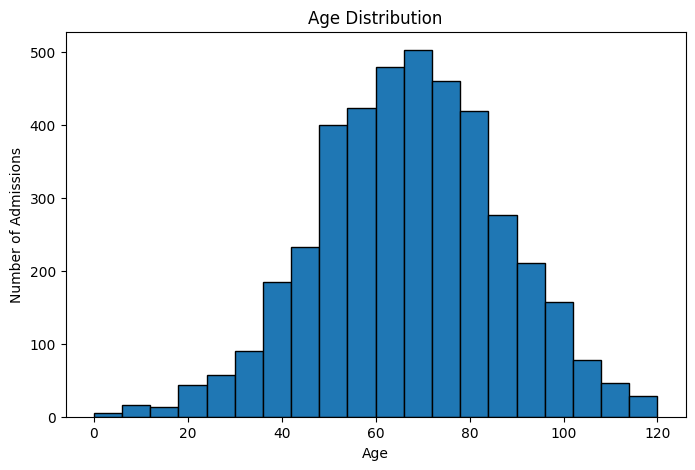

In [613]:
# Age Distribution graph
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Admissions')
plt.show()

# Length of Stay Distribution

Most data points cluster around the median length of stay (7). Only 25% of admissions had a length of stay of 9 days or above. Anything over 20 days appears to be an outlier with 40 being the highest. 

In [614]:
# Length of Stay statistics
df['length_of_stay'].describe()

count    4120.000000
mean        7.456553
std         3.788478
min         1.000000
25%         5.000000
50%         7.000000
75%         9.000000
max        40.000000
Name: length_of_stay, dtype: float64

In [615]:
print(f"Median Length of Stay: {df['length_of_stay'].median()}")

Median Length of Stay: 7.0


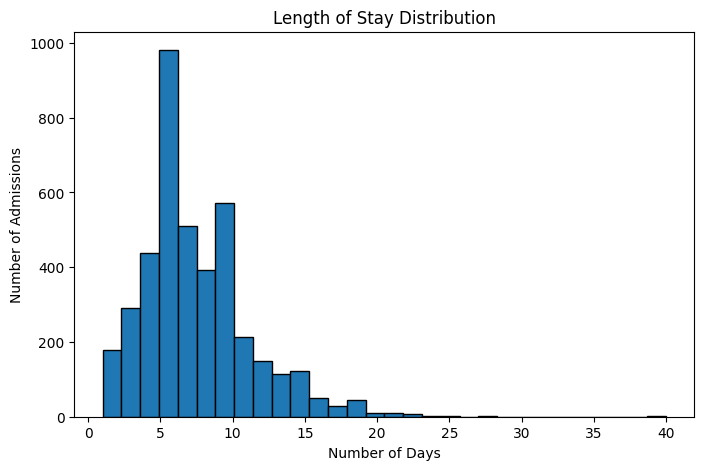

In [616]:
# Length of Stay Distribution graph
plt.figure(figsize=(8, 5))
plt.hist(df['length_of_stay'], bins=30, edgecolor='black')
plt.title('Length of Stay Distribution')
plt.xlabel('Number of Days')
plt.ylabel('Number of Admissions')
plt.show()

# Length of Stay by Admission Type  
Emergency admissions stayed 2 days longer on average than elective admissions.

In [617]:
# Length of Stay by Admission Type statistics
df.groupby('admission_type')['length_of_stay'].describe()

,count,mean,std,min,25%,50%,75%,max
admission_type,,,,,,,,
Elective,1338.0,6.038117,3.558156,1.0,3.0,5.0,8.0,25.0
Emergency,2782.0,8.138749,3.706435,3.0,6.0,7.0,10.0,40.0


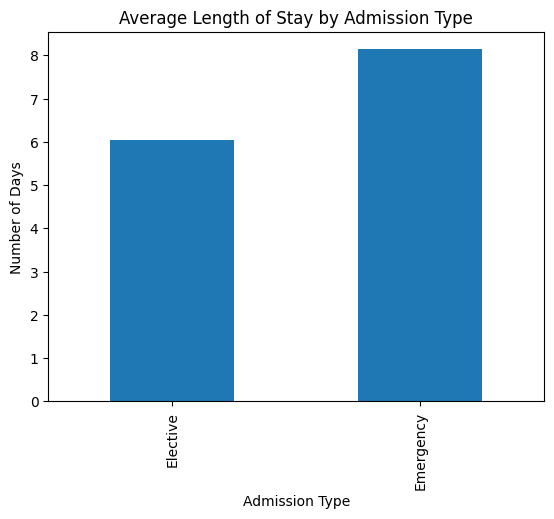

In [618]:
# Average Length of Stay by Admission Type bar graph
df.groupby('admission_type')['length_of_stay'].mean().plot(kind='bar')
plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Days')
plt.show()


# Length of Stay by Ward  
There is vary little variance between the length of stay per ward. The only significant observation is that the maximum length of stay for a surgical case is 40 days which is 12 days higher than the next maximum length of stay on the Orthopaedics ward. 

In [619]:
# Length of Stay by Ward statistics
df.groupby('ward')['length_of_stay'].describe()

,count,mean,std,min,25%,50%,75%,max
ward,,,,,,,,
Cardiology,619.0,7.462036,3.837276,1.0,5.0,7.0,9.00,27.0
Elderly Care,639.0,7.453834,3.695797,1.0,5.0,7.0,10.00,25.0
Medical,594.0,7.597643,3.791096,1.0,5.0,7.0,10.00,21.0
Orthopaedics,536.0,7.188433,3.723622,1.0,5.0,6.0,9.00,28.0
Respiratory,586.0,7.459044,3.735145,1.0,5.0,7.0,9.00,27.0
Stroke Unit,592.0,7.386824,3.824495,1.0,5.0,7.0,9.00,24.0
Surgical,554.0,7.633574,3.917461,1.0,5.0,7.0,9.75,40.0


In [620]:
# Average Length of Stay by Ward
avg_ward_los = df.groupby('ward')['length_of_stay'].mean().sort_values(ascending=False)
avg_ward_los

ward
Surgical        7.633574
Medical         7.597643
Cardiology      7.462036
Respiratory     7.459044
Elderly Care    7.453834
Stroke Unit     7.386824
Orthopaedics    7.188433
Name: length_of_stay, dtype: float64

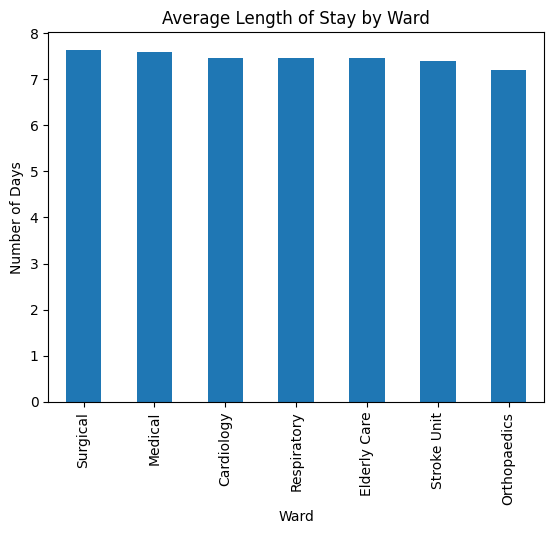

In [621]:
# Average Length of Stay by Ward graph
avg_ward_los.plot(kind='bar')
plt.title('Average Length of Stay by Ward')
plt.xlabel('Ward')
plt.ylabel('Number of Days')
plt.show()

# Length of Stay by Age Group  
Patients who were 75+ stayed, on average, 2 days longer than any other age group. There are also no cases of a patient aged 75+ who was discharged within 1 day. 

In [622]:
bins = [0, 14, 24, 44, 59, 74, float('inf')]
labels = ['0-14', '15-24', '25-44', '45-59', '60-74', '75+']

df['age_bracket'] = pd.cut(df['age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Length of Stay by Age Group statistics
df.groupby('age_bracket')['length_of_stay'].describe()


/var/folders/z8/rcsh9fvj18j0snmm09x520s80000gn/T/ipykernel_93318/4277922664.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bracket')['length_of_stay'].describe()


,count,mean,std,min,25%,50%,75%,max
age_bracket,,,,,,,,
0-14,26.0,6.576923,3.336742,1.0,4.25,6.0,8.0,16.0
15-24,55.0,6.054545,3.783092,1.0,3.00,5.0,8.0,17.0
25-44,437.0,6.768879,4.059663,1.0,4.00,6.0,9.0,40.0
45-59,948.0,6.779536,3.612854,1.0,4.00,6.0,9.0,27.0
60-74,1204.0,6.647841,3.528377,1.0,4.00,6.0,8.0,27.0
75+,1450.0,8.846897,3.638610,2.0,6.00,8.0,11.0,28.0


/var/folders/z8/rcsh9fvj18j0snmm09x520s80000gn/T/ipykernel_93318/3947738929.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bracket')['length_of_stay'].mean().plot(kind='bar')


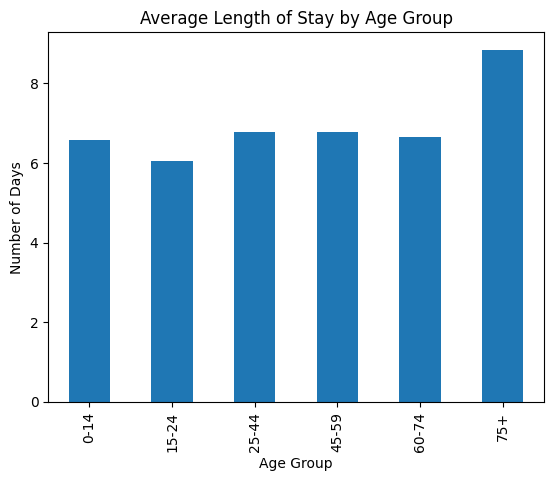

In [623]:
# Average Length of Stay by Age Group graph
df.groupby('age_bracket')['length_of_stay'].mean().plot(kind='bar')
plt.title('Average Length of Stay by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Days')
plt.show()

# Monthly Analytics

# Admissions per Month  
There is a significantly higher volume of admissions at the beginning of the year. Admissions are at their lowest in June.

In [624]:
# Monthly Admissions Numbers
monthly_admissions = df.groupby(df['admission_date'].dt.month).size()
monthly_admissions

admission_date
1     477
2     418
3     312
4     317
5     337
6     283
7     323
8     356
9     325
10    313
11    318
12    341
dtype: int64

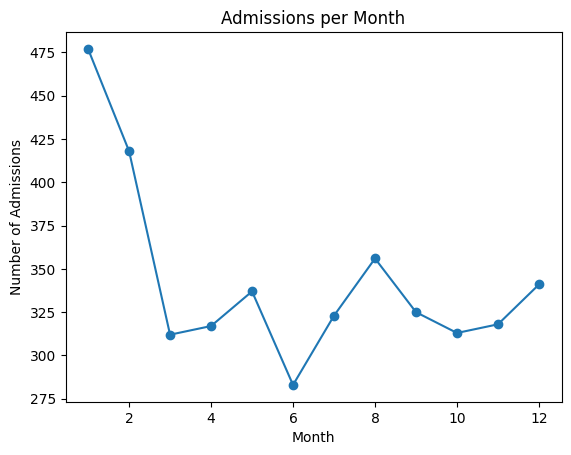

In [625]:
# Admissions per Month line graph
monthly_admissions.plot(marker='o')
plt.title('Admissions per Month')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.show()

# Average Length of Stay per Month  
The average length of stay appears consistent per month with no month raising above 7 days.

In [626]:
# Average Length of Stay per Month
avg_monthly_los = df.groupby(df['admission_date'].dt.month)['length_of_stay'].mean()

avg_monthly_los


admission_date
1     7.528302
2     7.925837
3     7.467949
4     7.302839
5     7.643917
6     7.134276
7     7.294118
8     7.210674
9     7.664615
10    7.469649
11    7.569182
12    7.090909
Name: length_of_stay, dtype: float64

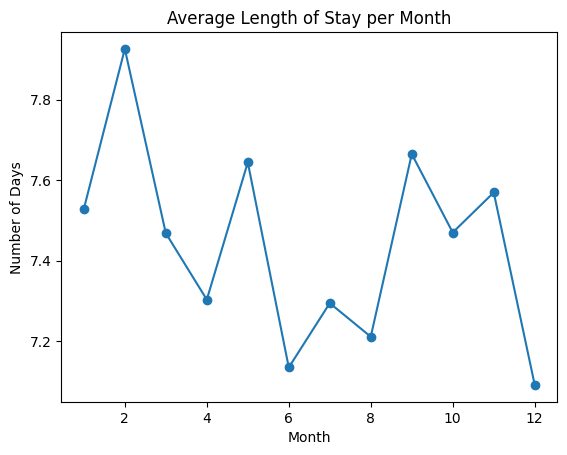

In [627]:
# Average Length of Stay per Month line graph
avg_monthly_los.plot(marker='o')
plt.title('Average Length of Stay per Month')
plt.xlabel('Month')
plt.ylabel('Number of Days')
plt.show()

# Readmission Analytics  
The overall readmission rate for the year is 11.5%.

In [628]:
# Overall Readmission rate
print(f"Overall Readmission rate: {df['readmission_30d'].mean() * 100:.2f}")

Overall Readmission rate: 11.50


# Readmission Rate by Ward  
The Respiratory ward has the highest rate of readmission followed by the Stroke Unit.

In [629]:
# Readmission rate by ward
ward_read_rate = df.groupby('ward')['readmission_30d'].mean() * 100
ward_read_rate

ward
Cardiology      10.177706
Elderly Care    11.580595
Medical          9.764310
Orthopaedics    10.447761
Respiratory     14.675768
Stroke Unit     13.006757
Surgical        10.830325
Name: readmission_30d, dtype: float64

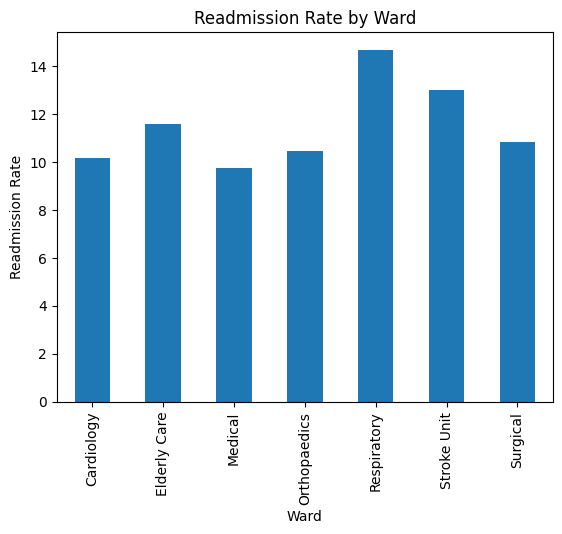

In [630]:
# Re-admission rate by ward bar graph
ward_read_rate.plot(kind='bar')
plt.title('Readmission Rate by Ward')
plt.xlabel('Ward')
plt.ylabel('Readmission Rate')
plt.show()

# Readmission Rate by Admission Type  
The readdmission rate is consistent between admission types.

In [631]:
# Readmission Rate by Admission Type statistics
df.groupby('admission_type')['readmission_30d'].mean() * 100

admission_type
Elective     11.509716
Emergency    11.502516
Name: readmission_30d, dtype: float64

# Correlation between Length of Stay and Readmission  
There is a very weak correlation between length of stay and readmission, but nothing strong enough to form any concrete conclusions.

In [632]:
# Correlation between Length of Stay and Readmission
df['length_of_stay'].corr(df['readmission_30d'])

np.float64(0.10253351879484503)

# Readmission Rate by Age Group  
Patients between the ages of 15 and 24 had the highest readmission rate (16.36%). There are only 55 (1.33%) patients who fall under this age bracket in the dataset. 

In [633]:
# Readmission Rate by Age Group
readmission_age = df.groupby('age_bracket')['readmission_30d'].mean() * 100
readmission_age

/var/folders/z8/rcsh9fvj18j0snmm09x520s80000gn/T/ipykernel_93318/957786452.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  readmission_age = df.groupby('age_bracket')['readmission_30d'].mean() * 100


age_bracket
0-14      3.846154
15-24    16.363636
25-44     9.382151
45-59    11.814346
60-74    11.046512
75+      12.275862
Name: readmission_30d, dtype: float64

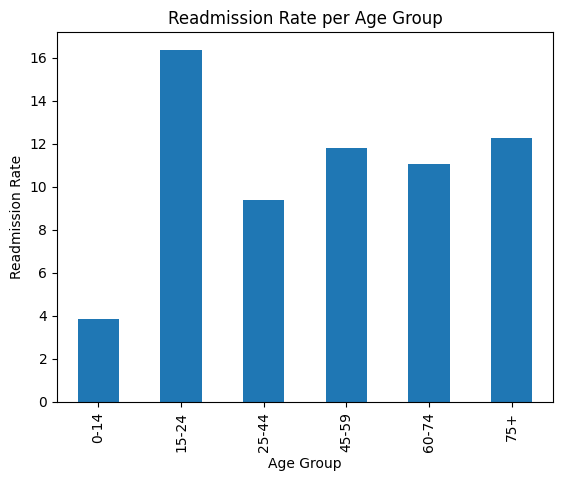

In [634]:
readmission_age.plot(kind='bar')
plt.title('Readmission Rate per Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate')
plt.show()

In [635]:
# Number of patients per age group
df.groupby('age_bracket')['patient_id'].count()

/var/folders/z8/rcsh9fvj18j0snmm09x520s80000gn/T/ipykernel_93318/404680134.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bracket')['patient_id'].count()


age_bracket
0-14       26
15-24      55
25-44     437
45-59     948
60-74    1204
75+      1450
Name: patient_id, dtype: int64

# Daily Bed Occupancy (in number of beds)
**Minimum:** 0
**Maximim:** 133
**Median:** 81
**Average:** 84.17

The highest number of beds were recorded in January and February with numbers beginning to rise again from Novemebr through December.

# Occupancy Rate
**Minimum:** 0%
**Maximim:** 44.33%
**Median:** 27%
**Average:** 28.06%  
  
**Total Number of Beds in Hospital:** 300  

The hospital always operates under the recommend safety threshold of 85%.

**Source for Threshold Number:** https://www.bma.org.uk/advice-and-support/nhs-delivery-and-workforce/pressures/nhs-hospital-beds-data-analysis#:~:text=Rising%20occupancy,It%20can:

In [636]:
# Create new data frame to show how many beds are occupied each day
date_range = pd.date_range(df['admission_date'].min(), df['discharge_date'].max())

daily_occupancy = []

for date in date_range:
    number_of_admissions = df[(df['admission_date'] <= date) & (df['discharge_date'] > date)].shape[0]

    daily_occupancy.append({
        'date': date,
        'occupied_beds': number_of_admissions
    })

daily_occupancy_df = pd.DataFrame(daily_occupancy)

TOTAL_BEDS = 300 # Number of beds in hospital

daily_occupancy_df['occupancy_rate'] = (daily_occupancy_df['occupied_beds'] / TOTAL_BEDS) * 100

daily_occupancy_df.describe()

# Export data frame to csv to use in dashboard
daily_occupancy_df.to_csv('daily_occupancy.csv', index=False)

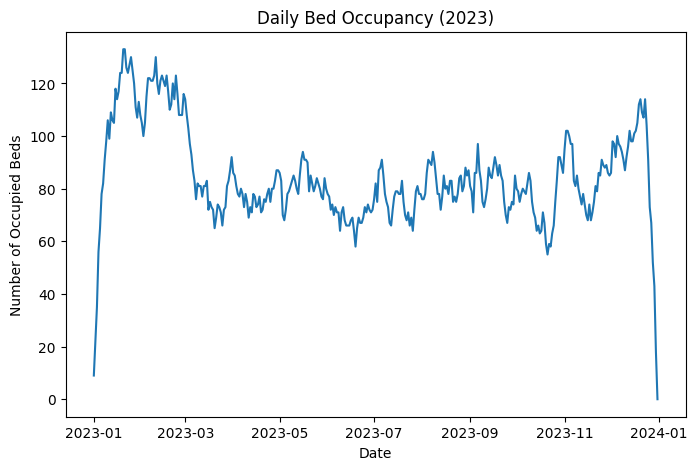

In [637]:
plt.figure(figsize=(8,5))
plt.plot(daily_occupancy_df['date'], daily_occupancy_df['occupied_beds'])
plt.title('Daily Bed Occupancy (2023)')
plt.xlabel('Date')
plt.ylabel('Number of Occupied Beds')
plt.show()

In [638]:
# Dates with the highest number of patients in hospital
max_beds = daily_occupancy_df['occupied_beds'].max()
daily_occupancy_df[daily_occupancy_df['occupied_beds'] == max_beds]

,date,occupied_beds,occupancy_rate
19,2023-01-20,133,44.333333
20,2023-01-21,133,44.333333


In [639]:
# Dates with the lowest number of patients in hospital
min_beds = daily_occupancy_df['occupied_beds'].min()
daily_occupancy_df[daily_occupancy_df['occupied_beds'] == min_beds]

,date,occupied_beds,occupancy_rate
364,2023-12-31,0,0.0


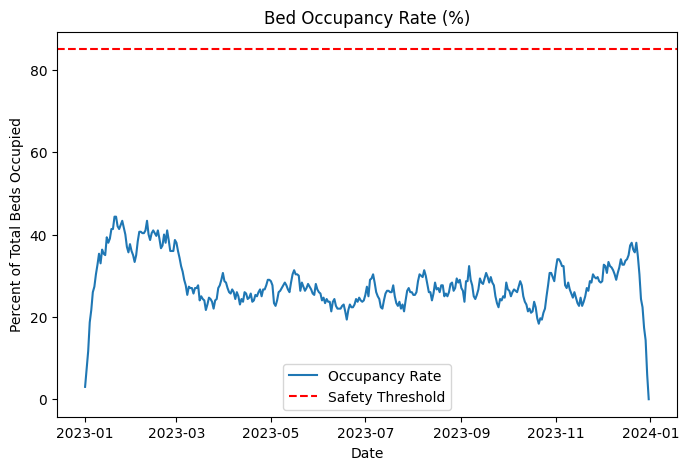

In [640]:
plt.figure(figsize=(8,5))
plt.plot(daily_occupancy_df['date'], daily_occupancy_df['occupancy_rate'], label='Occupancy Rate')
plt.axhline(85, linestyle= '--', color='red', label='Safety Threshold')
plt.title('Bed Occupancy Rate (%)')
plt.xlabel('Date')
plt.ylabel('Percent of Total Beds Occupied')
plt.legend()
plt.show()




# Operational Insights

## Length of Stay (Compared to Source 1)  
The average length of stay for 2023 was 7.46 days. This is almost 1 day lower than mean length of stay in an NHS hospital in 2022 (8.3). It is slightly higher than the mean for an NHS hospital in 2019 (7.3). This indicates that the hospital is performing, on average, about the same as other hospitals in the United Kingdom. Minimal variation between wards indicates that the case complexity within the dataset may have been similar. The average length of stay was slightly higher for the Surgical ward, but still within the 7 day average. However, the maximum length of stay for this ward was 40 days, which may indicate an individual case with complications leading to delayed discharge.

The mean length of stay for an elective procedure was 6.04 days. This is one day above the national averages for 2019 (5.2) and 2022 (5.1). This may indicate that staff were performing different or more complicated procedures than may be performed at other hospitals. The mean length of stay for an emergency admission was 8.14 days. This falls between the national means for 2019 (7.9) and 2022 (9.1).

## Readmissions (Compared to Source 2)
The 30-day readmission rate (11.5%) was significantly lower than the national average for 2020/2021 (15.5%). This may indicate differences in discharge planning or local patient demographics.

The readmission rate was also higher (14.68%) for the Respiratory ward than all other wards. This could be an indicator of the difficulty of these cases or a need for extra interventions.

## Age Patterns (Compared to Source 1)
Patients who were 75+ spent 2 more days admitted compared to other age groups. This difference may be explained by the comorbidities that are often associated with age. It should be noted, however, that the average length of stay for these patients was less than the national average which lists 8.9 days in 2019 and 10.2 days in 2022 for ages 65-84 and 10.8 and 12.5 days for patietns 85+. Consdiering that the majority of the data in this dataset skews towards older patients, this indicates that the hospital may be bettter equipped to meet the neess of elderly patients.

The high admission rate amongst the 15-24 age group (16.36%) is a concern. However, since this demographic only makes up (1.33%) of the dataset, it is possible that the results may be skewed towards a small number of cases. This should be evaluated further to check whether it is a genuine trend or a result of the small sample set. 


**Source 1:** https://www.health.org.uk/reports-and-analysis/briefings/longer-hospital-stays-and-fewer-admissions  
**Source 2:** https://www.nuffieldtrust.org.uk/resource/emergency-readmissions#:~:text=How%20have%20emergency%20readmissions%20within,from%20hospital%20changed%20over%20time?&text=In%202020/21%2C%20the%20first,emergency%20readmissions%20rose%20to%2015.5%25.  

# Limitations
- Due to patient confidentiality laws, this dataset has been simulated and does not reflect true clinical data. The complexity of cases is therefore unknown.
- Patients were randomly allocated to wards in this dataset with no respect for age. Distributions may not align with normal clinical patterns of observation.
- This dataset is limited to one year and one hospital, making it difficult to judge the performance of the hospital over time. It also make it difficult to compare the dataset to other hospitals or the national average since the cases the patients present may differ.
- The small proportion of younger age groups makes it difficult to form conclusions about these demographics.
- The limited length of stay variation between wards makes it difficult to compare different medical specialties.

# Recommendations
- Review triage and discharge procedures. Spend extra time with patients in the 15-24 age bracket in order to get a fuller picture of their symptoms. Review discharge procedures and make sure patients understand any instructions given to them.
- Create a risk assessment to identify factors that lead to readmission. Explore the possibility of closer monitoring and additional interventions for Respiratory patients.
- Consider recruiting or offering additonal training to staff who deal with complex cases in order to reduce above average length of stays.
- Consider hiring additional staff during winter months to anticipate the higher admission trends.
- Add bed information to future datasets to calculate individual ward occupancy and capacity.
